In [1]:
import os 
import json

def load_files(path, file_type='analysis'):
    audio_files = []
    
    for root, dirs, files in os.walk(path):
        for file in files:
            if file_type == 'normalized' and file.endswith("_normalized.json"):
                audio_files.append(os.path.join(root, file))
            elif file_type == 'analysis' and file.endswith("_analysis.json"):
                audio_files.append(os.path.join(root, file))
            elif file_type == 'vocab_corrected' and file.endswith("_vocab_corrected.json"):
                audio_files.append(os.path.join(root, file))
    return audio_files

In [2]:
# Define your collections and path
collections = ["lastfm", "suno", "udio"]
base_path = "../dataset_corrected/"
type = "vocab_corrected"  

# Gather all jsons per collection
all_jsons = {}
for col in collections:
    dataset_path = f"{base_path}/{col}"
    all_jsons[col] = load_files(dataset_path, type)

# Optional: Print counts
for col in collections:
    print(f"{col}: {len(all_jsons[col])} JSON files")

lastfm: 19853 JSON files
suno: 19972 JSON files
udio: 19992 JSON files


In [3]:
# Sets for collecting unique chords
unique_chords = set()
unique_functional_chords = set()

# Loop over files and extract chords
for col, files in all_jsons.items():
    for file_path in files:
        with open(file_path, 'r') as f:
            data = json.load(f)
            for chord in data.get("chords", []):
                # Get chord name
                chord_name = chord.get("chord_name", "")
                if chord_name:
                    unique_chords.add(chord_name)
                
                # Get full functional harmony as a string or tuple
                fh = chord.get("functional_harmony", {})
                if fh:
                    functional_str = f"{fh.get('functional', '')}|{fh.get('alterations', '')}|{fh.get('roman_numeral', '')}"
                    unique_functional_chords.add(functional_str)

# Results
print(f"Total unique chord names: {len(unique_chords)}")
print(f"Total unique functional chords: {len(unique_functional_chords)}")

# Optional: list some of them
print("\nExamples of unique chord names:")
print(sorted(list(unique_chords))[:10])

print("\nExamples of unique functional chords:")
print(sorted(list(unique_functional_chords))[:10])

Total unique chord names: 392
Total unique functional chords: 841

Examples of unique chord names:
['A', 'A#', 'A#7', 'A#7#11', 'A#7#9', 'A#7alt', 'A#7b13', 'A#7b9', 'A#7sus', 'A#7sus4']

Examples of unique functional chords:
['#III|+|#III+', '#III|7532|#III7532', '#III|753b2|#III753b2', '#III|7|#III7', '#III|b75#43|#IIIb75#43', '#III|b753#2|#IIIb753#2', '#III|b7532|#IIIb7532', '#III|b753b2|#IIIb753b2', '#III|b753|#IIIb753', '#III|b7b653|#IIIb7b653']


In [4]:
import re

# Sets for vocabularies
root_vocabulary = set()
quality_vocabulary = set()

# Define root patterns manually (to ensure correct parsing)
all_roots = [
    "C", "C#", "Db", "D", "D#", "Eb", "E", "E#", "Fb", "F", "F#", "Gb",
    "G", "G#", "Ab", "A", "A#", "Bb", "B", "B#", "Cb"
]

# Sort roots by length descending to prioritize sharp/flat over base note
all_roots_sorted = sorted(all_roots, key=lambda x: -len(x))

for chord_name in unique_chords:
    root_found = False
    for root in all_roots_sorted:
        if chord_name.startswith(root):
            root_vocabulary.add(root)
            quality = chord_name[len(root):]
            quality_vocabulary.add(quality)
            root_found = True
            break
    if not root_found:
        print(f"Warning: Unrecognized root in chord name '{chord_name}'")

# Display results
print(f"\nTotal unique roots: {len(root_vocabulary)}")
print("Root vocabulary:", sorted(root_vocabulary))

print(f"\nTotal unique qualities: {len(quality_vocabulary)}")
print("Quality vocabulary:", sorted(quality_vocabulary))



Total unique roots: 19
Root vocabulary: ['A', 'A#', 'Ab', 'B', 'Bb', 'C', 'C#', 'Cb', 'D', 'D#', 'Db', 'E', 'Eb', 'F', 'F#', 'Fb', 'G', 'G#', 'Gb']

Total unique qualities: 23
Quality vocabulary: ['', '7', '7#11', '7#9', '7alt', '7b13', '7b9', '7sus', '7sus4', '9', 'aug', 'dim', 'dim7', 'm', 'm7', 'm7b5', 'm9', 'maj7', 'maj9', 'mmaj7', 'power', 'power9', 'sus4']


In [5]:
from collections import Counter
import json
import pandas as pd


# Color order: lastfm, suno, udio
colors = ["#51BFFF", "#FFC400", "#FF5B0E"]

# Your full quality vocabulary
quality_vocab = ['major', '7', '7#11', '7#9', '7alt', '7b13', '7b9', '7sus', '7sus4',
                 'aug', 'dim', 'dim7', 'm', 'm7', 'm7b5', 'm9', 'maj7', 'maj9',
                 'mmaj7', 'power', 'power9', 'sus4']


# ---- 1. Load all chords into a DataFrame (ONE PASS) ----
all_chords = []
for col, files in all_jsons.items():
    for file_path in files:
        with open(file_path, 'r') as f:
            data = json.load(f)
            for chord in data.get("chords", []):
                chord_name = chord.get("chord_name", "")
                all_chords.append({
                    "collection": col,
                    "chord_name": chord_name
                })
df = pd.DataFrame(all_chords)

# ---- 2. Extract quality for each chord ----
def extract_quality(chord_name):
    for root in all_roots_sorted:
        if chord_name.startswith(root):
            q = chord_name[len(root):]
            return 'major' if q == '' else q
    return 'major'

df['quality'] = df['chord_name'].apply(extract_quality)
df['quality'] = df['quality'].replace('9', '7')

# ---- 3. Count quality occurrences per collection ----
df_quality = pd.DataFrame({
    col: [df[df['collection'] == col]['quality'].value_counts().get(q, 0) for q in quality_vocab]
    for col in collections
}, index=quality_vocab)

print(df_quality)

# ---- 4. Unique chord types per collection ----
unique_counts = {col: (df_quality[col] > 0).sum() for col in collections}
print("\nUnique chord qualities per collection:", unique_counts)

#Sort from highest to lowest
df_quality = df_quality.sort_values(by=collections, ascending=False)

         lastfm     suno    udio
major   1491512  1257337  808020
7        938057   503592  495087
7#11      15352     3635    7576
7#9        7321     1698    3317
7alt       7235     1968    3881
7b13      19607     9720   11498
7b9      167898    48191   77421
7sus      55428    25389   32737
7sus4    265575   114689  153996
aug       46182    13695   23637
dim       57051    16949   30083
dim7      73156    17897   36077
m        698460   545815  421449
m7       235196   154703  154238
m7b5     130988    36502   67946
m9        37424    15530   22602
maj7     347653   188779  193723
maj9      37533    19701   26939
mmaj7      3200      861    1924
power   1320126  1213894  785583
power9    26584    10243   13595
sus4     951972   579784  530117

Unique chord qualities per collection: {'lastfm': 22, 'suno': 22, 'udio': 22}


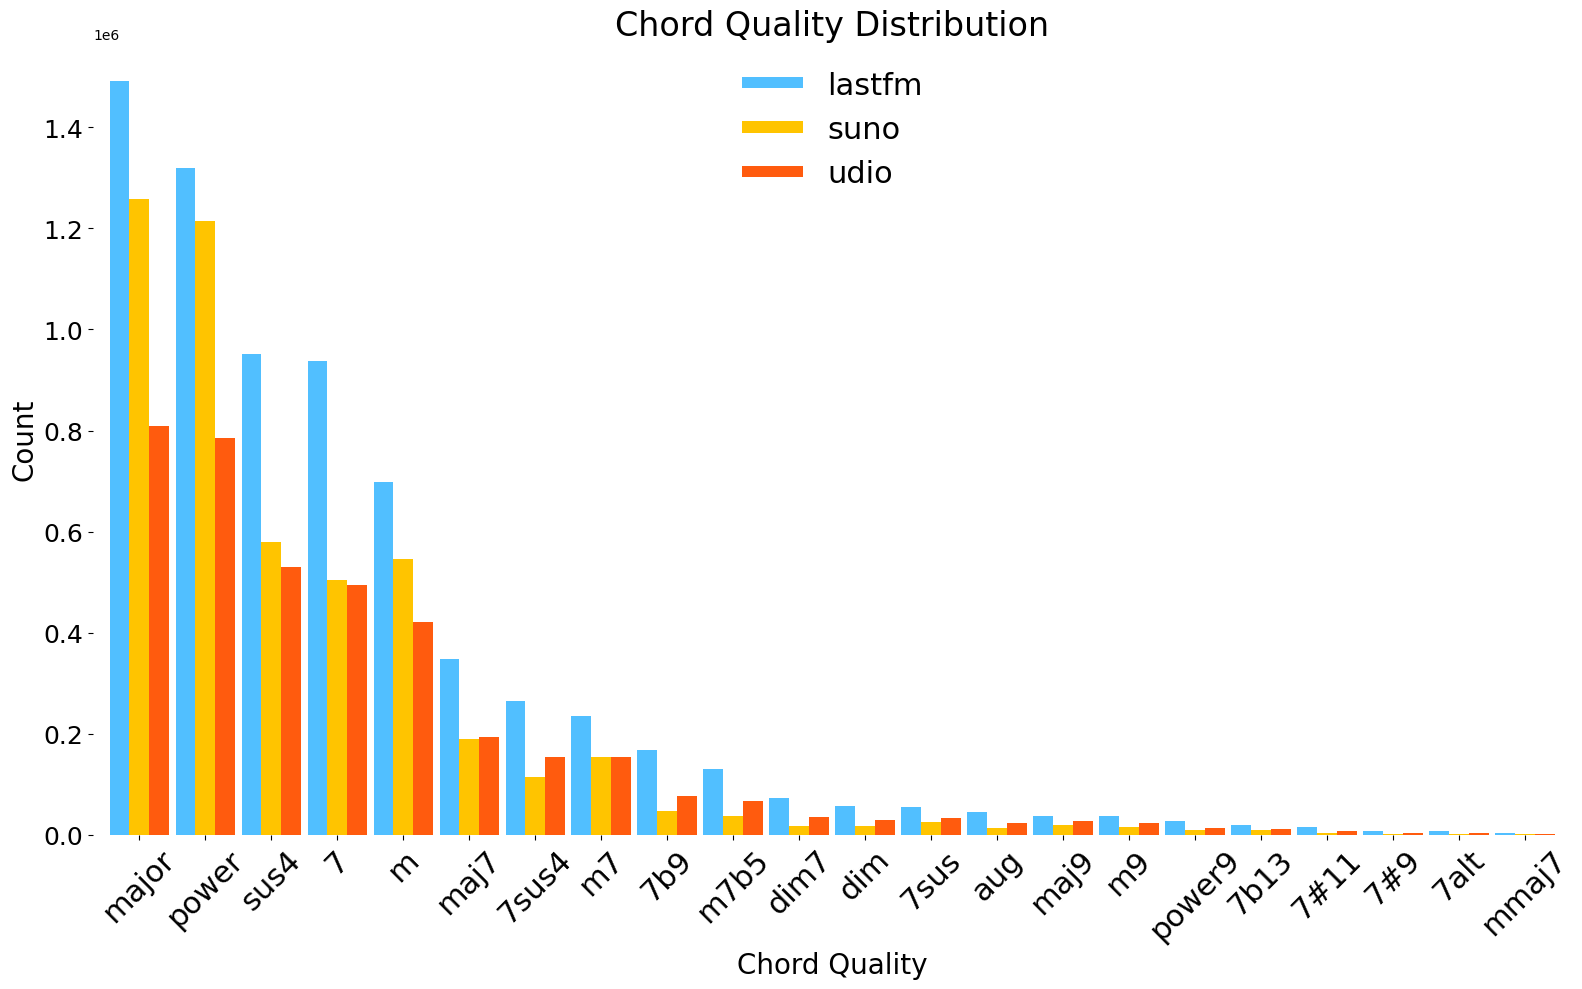

In [ ]:
import matplotlib.pyplot as plt

bar_colors = [colors[collections.index(col)] for col in df_quality.columns]

ax = df_quality.plot.bar(
    figsize=(16, 9),
    color=bar_colors,
    width=0.9
)

plt.title("Chord Quality Distribution", fontsize=24, fontweight='normal')
plt.xlabel("Chord Quality", fontsize=20, fontweight='normal')
plt.ylabel("Count", fontsize=20, fontweight='normal')
plt.xticks(rotation=45, fontsize=22, fontweight='normal')
plt.yticks(fontsize=18, fontweight='normal')

plt.legend(
    title='',
    fontsize=22,
    title_fontsize=20,
    frameon=False,
    loc='upper center',
    handleheight=0.2,   # Default is 2, try 1 or 0.8
    handlelength=2.  # Default is 2, can also adjust
)

# Remove all plot borders/frames
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()
